### Wine Quality dataset - Decision Tree Classifier

#### Andres Cruz Chipol

Originally a regression dataset, it must be adapted/discretized into distinct
classes to evaluate wine quality characteristics.


url:https://archive.ics.uci.edu/dataset/186/wine+quality

###  Phase A: Data Preprocessing
Load the datasets into your chosen development environment (Python with scikit-learn or R with
rpart are highly recommended).
Handle missing values professionally using justified imputation or row-removal techniques.
Encode categorical variables appropriately (e.g., One-Hot Encoding or Label Encoding).
Split each dataset into a balanced Training Set and Testing Set.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataRed = pd.read_csv('winequality-red.csv', sep=';')
dataWhite = pd.read_csv('winequality-white.csv', sep=';')

In [2]:
# Parece que no existen valores nulos en el dataset.
dataRed.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [3]:
dataWhite.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

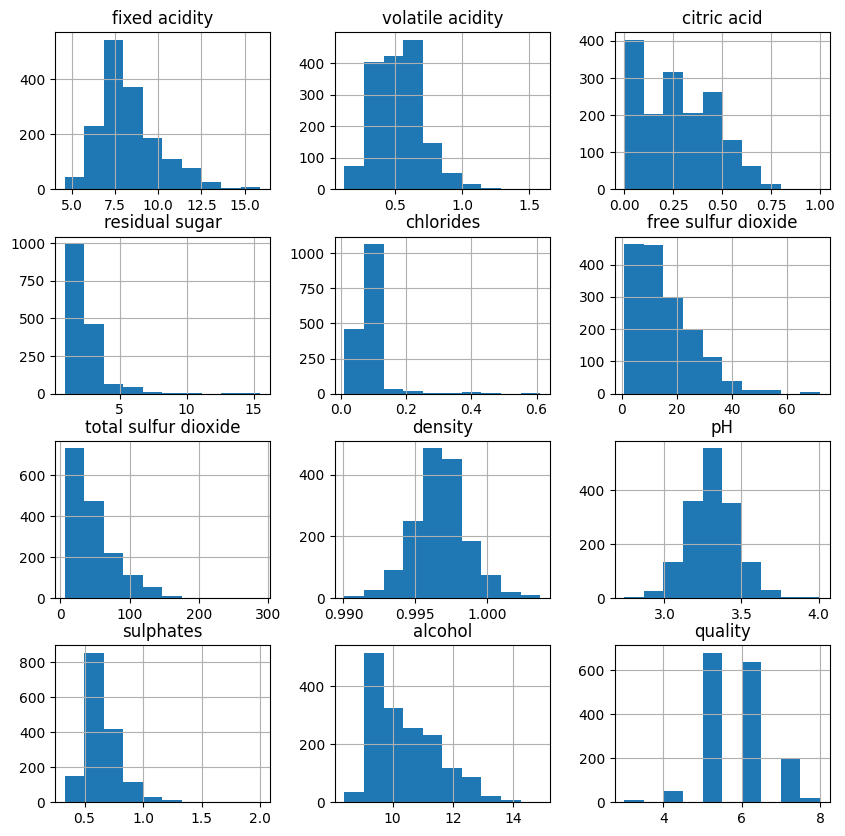

In [4]:
# Di un vistazo a los datos para ver qué tipo de información tenemos.
# Revise que todas eran numericas, asi que me interesaria hacer un hist de sus distribuciones y ver si hay alguna que se vea rara.
dataRed.hist(figsize=(10, 10))

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

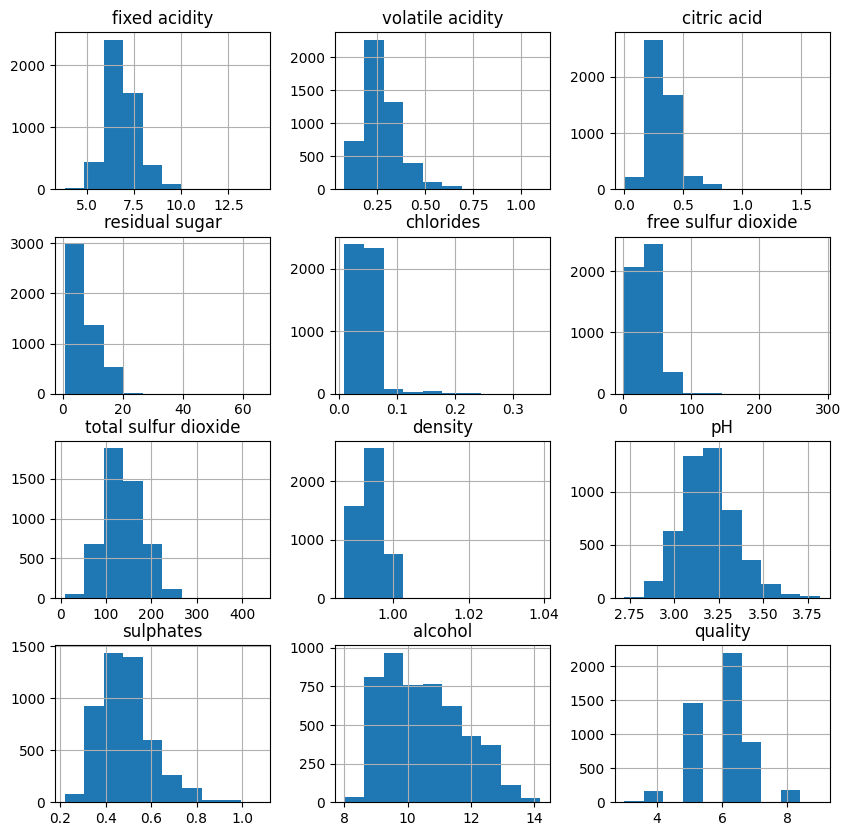

In [5]:
dataWhite.hist(figsize=(10, 10))

<Axes: >

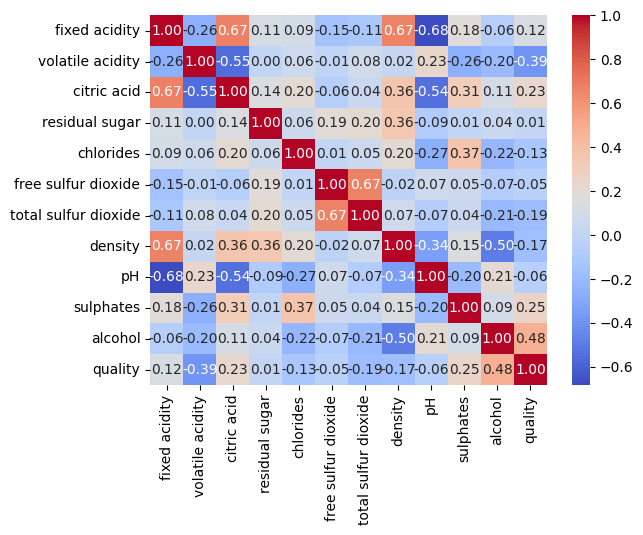

In [6]:
# Revisaremos sus correlacione
sns.heatmap(dataRed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
# valores interesantes:
# fixed acidity - citric acid: 0.67
# density - alcohol: -0.50
# alcohol - quality: 0.48
# fixed acidity - pH: -0.68
# fixed acidity - density: 0.67
# citric acid - pH: -0.54
# free sulfur dioxide - total sulfur dioxide: 0.67

# Como podemos ver, los acidos estan correlacionados, nos quedaremos con fixed acidity,volatil, citric acid, ya que son los que tienen
# mayor correlacion con quality.

# Crearemos la variable free sulfur dioxide - total sulfur dioxide, eliminando las dos variables y quedandonos con la nueva variable.

# Crearemos el ratio_density_alcohol = density / alcohol, ya que density y alcohol estan correlacionados, y el ratio nos puede dar una mejor idea de la calidad del vino.


<Axes: >

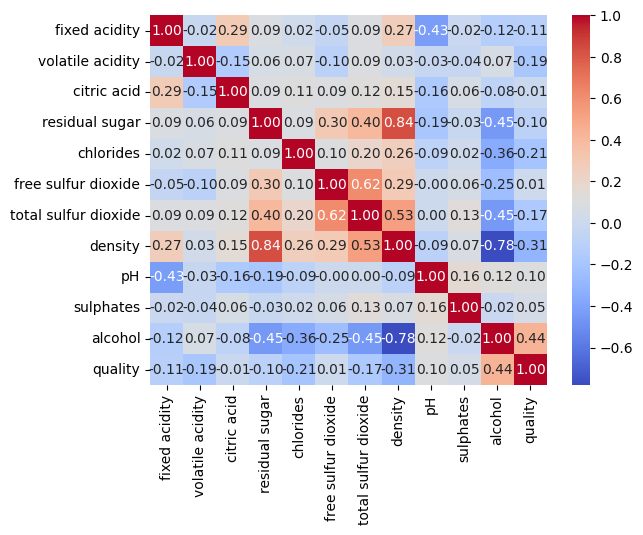

In [7]:
sns.heatmap(dataWhite.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# en el caso del white:
# ph - fixed acidity: -0.43
# free sulfur dioxide - residual sugar: 0.30
# total sulfur dioxide - residual sugar: 0.40
# density - residual sugar: 0.45
# alcohol - chlorides: -0.36
# total sulfur dioxide - free sulfur dioxide: 0.62
# density - total sulfur dioxide: -0.53
# alcohol - total sulfur dioxide: -0.45
# alcohol - density: -0.78
# quality - alcohol: 0.44

# Aqui eliminamos densidad por  ratio_alc_dens (alcohol / density).
# Eliminamos el ph y nos quedamos con los acidos, ya que tienen mayor correlacion con quality.
# creamos igual el free sulfur dioxide - total sulfur dioxide, eliminando las dos variables y quedandonos con la nueva variable.

# Parece que el azucar importa mas en el vino blanco que en el tinto, ya que tiene mayores correlaciones.

In [8]:
# Eliminando el ph
dataRed = dataRed.drop(columns=['pH'])
# Crearemos la variable free sulfur dioxide - total sulfur dioxide, eliminando las dos variables y quedandonos con la nueva variable.
dataRed['free_total_sulfur_dioxide'] = dataRed['free sulfur dioxide'] - dataRed['total sulfur dioxide']
dataRed = dataRed.drop(columns=['free sulfur dioxide', 'total sulfur dioxide'])
# Crearemos el ratio_density_alcohol = density / alcohol, ya que density y alcohol estan correlacionados, y el ratio nos puede dar una mejor idea de la calidad del vino.
dataRed['ratio_density_alcohol'] = dataRed['density'] / dataRed['alcohol']
dataRed = dataRed.drop(columns=['density'])

In [9]:
#Para el vino blanco
dataWhite = dataWhite.drop(columns=['pH'])

# Aqui eliminamos densidad por  ratio_alc_dens (alcohol / density).
dataWhite['ratio_alc_dens'] = dataWhite['alcohol'] / dataWhite['density']
# creamos igual el free sulfur dioxide - total sulfur dioxide, eliminando las dos variables y quedandonos con la nueva variable.
dataWhite['free_total_sulfur_dioxide'] = dataWhite['free sulfur dioxide'] - dataWhite['total sulfur dioxide']
dataWhite = dataWhite.drop(columns=['free sulfur dioxide', 'total sulfur dioxide', 'density'])


In [10]:
dataRed.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,sulphates,alcohol,quality,free_total_sulfur_dioxide,ratio_density_alcohol
0,7.4,0.70,0.00,1.9,0.076,0.56,9.4,5,-23.0,0.106149
1,7.8,0.88,0.00,2.6,0.098,0.68,9.8,5,-42.0,0.101714
2,7.8,0.76,0.04,2.3,0.092,0.65,9.8,5,-39.0,0.101735
3,11.2,0.28,0.56,1.9,0.075,0.58,9.8,6,-43.0,0.101837
4,7.4,0.70,0.00,1.9,0.076,0.56,9.4,5,-23.0,0.106149
5,7.4,0.66,0.00,1.8,0.075,0.56,9.4,5,-27.0,0.106149
6,7.9,0.60,0.06,1.6,0.069,0.46,9.4,5,-44.0,0.106000
7,7.3,0.65,0.00,1.2,0.065,0.47,10.0,7,-6.0,0.099460
8,7.8,0.58,0.02,2.0,0.073,0.57,9.5,7,-9.0,0.104926
9,7.5,0.50,0.36,6.1,0.071,0.80,10.5,5,-85.0,0.095029


In [11]:
dataWhite.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,sulphates,alcohol,quality,ratio_alc_dens,free_total_sulfur_dioxide
0,7.0,0.27,0.36,20.7,0.045,0.45,8.8,6,8.791209,-125.0
1,6.3,0.30,0.34,1.6,0.049,0.49,9.5,6,9.557344,-118.0
2,8.1,0.28,0.40,6.9,0.050,0.44,10.1,6,10.149734,-67.0
3,7.2,0.23,0.32,8.5,0.058,0.40,9.9,6,9.943753,-139.0
4,7.2,0.23,0.32,8.5,0.058,0.40,9.9,6,9.943753,-139.0
5,8.1,0.28,0.40,6.9,0.050,0.44,10.1,6,10.149734,-67.0
6,6.2,0.32,0.16,7.0,0.045,0.47,9.6,6,9.649211,-106.0
7,7.0,0.27,0.36,20.7,0.045,0.45,8.8,6,8.791209,-125.0
8,6.3,0.30,0.34,1.6,0.049,0.49,9.5,6,9.557344,-118.0
9,8.1,0.22,0.43,1.5,0.044,0.45,11.0,6,11.068625,-101.0


<Axes: title={'center': 'Distribucion de calidad del vino tinto'}, xlabel='quality'>

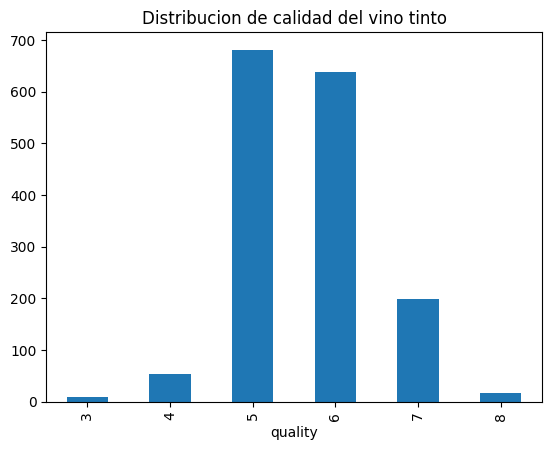

In [12]:
# La distribucion de calidad esta desbalanceada, revisaremos.
dataRed['quality'].value_counts().sort_index().plot(kind='bar', title='Distribucion de calidad del vino tinto')

<Axes: title={'center': 'Distribucion de calidad del vino blanco'}, xlabel='quality'>

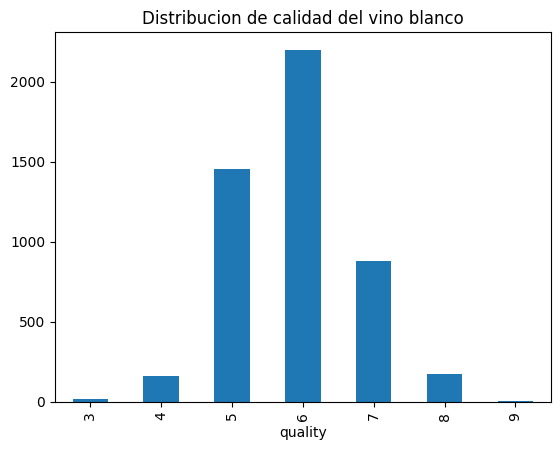

In [13]:
dataWhite['quality'].value_counts().sort_index().plot(kind='bar', title='Distribucion de calidad del vino blanco')

In [14]:
# Vamos a discretizar la variable calidad en 3 categorias: baja, media y alta.
dataRed['quality'] = dataRed['quality'].apply(lambda x: 'baja' if x <= 4 else ('media' if x <= 6 else 'alta'))
dataWhite['quality'] = dataWhite['quality'].apply(lambda x: 'baja' if x <= 4 else ('media' if x <= 6 else 'alta'))

<Axes: title={'center': 'Distribucion de calidad del vino tinto (discretizada)'}, xlabel='quality'>

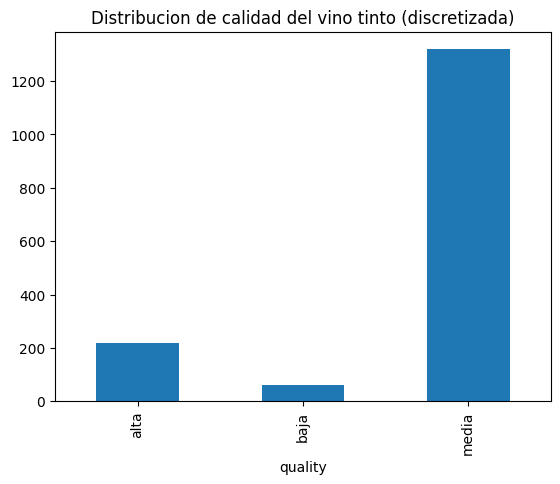

In [15]:
dataRed['quality'].value_counts().sort_index().plot(kind='bar', title='Distribucion de calidad del vino tinto (discretizada)')

<Axes: title={'center': 'Distribucion de calidad del vino blanco(discretizada)'}, xlabel='quality'>

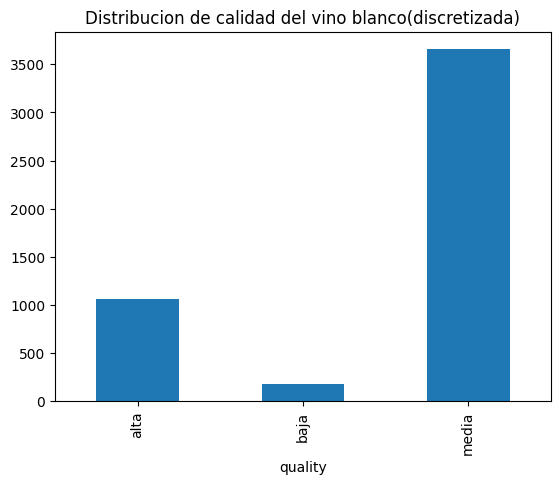

In [16]:
dataWhite['quality'].value_counts().sort_index().plot(kind='bar', title='Distribucion de calidad del vino blanco(discretizada)')

In [17]:
dataRed.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,sulphates,alcohol,quality,free_total_sulfur_dioxide,ratio_density_alcohol
0,7.4,0.70,0.00,1.9,0.076,0.56,9.4,media,-23.0,0.106149
1,7.8,0.88,0.00,2.6,0.098,0.68,9.8,media,-42.0,0.101714
2,7.8,0.76,0.04,2.3,0.092,0.65,9.8,media,-39.0,0.101735
3,11.2,0.28,0.56,1.9,0.075,0.58,9.8,media,-43.0,0.101837
4,7.4,0.70,0.00,1.9,0.076,0.56,9.4,media,-23.0,0.106149
5,7.4,0.66,0.00,1.8,0.075,0.56,9.4,media,-27.0,0.106149
6,7.9,0.60,0.06,1.6,0.069,0.46,9.4,media,-44.0,0.106000
7,7.3,0.65,0.00,1.2,0.065,0.47,10.0,alta,-6.0,0.099460
8,7.8,0.58,0.02,2.0,0.073,0.57,9.5,alta,-9.0,0.104926
9,7.5,0.50,0.36,6.1,0.071,0.80,10.5,media,-85.0,0.095029


In [18]:
# Aun discretizadas, vemos una alto desbalance, asi que usaremos el arbol con class_weight = 'balanced'
#  para que el arbol tenga en cuenta este desbalance.
# Ahora tenemos que recodificar la calidad a numerica, y dejaremos la columna al final del dataset, para que sea la ultima columna y no la primera, ya que es la variable objetivo.
quality_mapping = {'baja': 0, 'media': 1, 'alta': 2}

for df in [dataRed, dataWhite]:
    df['quality'] = df['quality'].astype(str).str.strip().map(quality_mapping)

    if 'quality' in df.columns:
        quality_column = df.pop('quality')
        df.insert(len(df.columns), 'quality', quality_column)


In [19]:
# Realizare un guardado del dataset limpio en un archivo CSV, para poder visualizarlo y que todo este correcto, y luego poder usarlo para entrenar el modelo de Decision Tree.
dataRed.to_csv('red_wine_clean.csv', index=False)
dataWhite.to_csv('white_wine_clean.csv', index=False)

In [20]:
# Limpiamos la memoria, eliminando las variables que ya no necesitamos.
del dataRed
del dataWhite

### Phase B: Model Building

Train a baseline Decision Tree classifier using the training partition.

Analyze the initial splitting criteria and structure generated by the algorithm. 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
# Carga de datos
dataRed = pd.read_csv('red_wine_clean.csv')
dataWhite = pd.read_csv('white_wine_clean.csv')

# Ahora creamos los dos datasets, uno para el vino tinto y otro para el vino blanco, y entrenaremos un modelo de Decision Tree para cada uno.

X_red = dataRed.drop('quality', axis=1)
y_red = dataRed['quality']

X_white = dataWhite.drop('quality', axis=1)
y_white = dataWhite['quality']


X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(X_red, y_red, test_size=0.2, random_state=42, stratify=y_red)
X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(X_white, y_white, test_size=0.2, random_state=42, stratify=y_white)

classifier_red = DecisionTreeClassifier(random_state=42, class_weight='balanced')
classifier_red.fit(X_train_red, y_train_red)

classifier_white = DecisionTreeClassifier(random_state=42, class_weight='balanced')
classifier_white.fit(X_train_white, y_train_white)

y_pred_red = classifier_red.predict(X_test_red)
y_pred_white = classifier_white.predict(X_test_white)

In [23]:
# Vamos a analizar la estructura del árbol generado y la importancia de las variables para entender cómo el modelo está tomando decisiones.

# Extraemos métricas de la estructura del árbol
max_depth = classifier_red.tree_.max_depth
leaves = classifier_red.get_n_leaves()
total_nodes = classifier_red.tree_.node_count

print(f"Profundidad máxima del árbol: {max_depth}")
print(f"Número de nodos hoja (reglas finales): {leaves}")
print(f"Número total de nodos en el árbol: {total_nodes}")

# Un árbol con una profundidad de más de 40 niveles y miles de hojas
# está claramente memorizando el conjunto de entrenamiento (sobreajuste).

feature_names = X_train_red.columns

# Análisis del Nodo Raíz a bajo nivel (Initial Splitting Criteria)
internal_tree = classifier_red.tree_
root_node = 0

feature_idx = internal_tree.feature[root_node]
feature_name = feature_names[feature_idx]
threshold = internal_tree.threshold[root_node]
impurity = internal_tree.impurity[root_node]
samples = internal_tree.n_node_samples[root_node]

print("\nCriterio de División Inicial (Root Node)")
print(f"Característica seleccionada : {feature_name}")
print(f"Valor umbral (Threshold)    : <= {threshold:.4f}")
print(f"Impureza inicial (Gini)     : {impurity:.4f}")
print(f"Total de muestras evaluadas : {samples}")

max_depth_white = classifier_white.tree_.max_depth
leaves_white = classifier_white.get_n_leaves()
total_nodes_white = classifier_white.tree_.node_count

print(f"\nProfundidad máxima del árbol (vino blanco): {max_depth_white}")
print(f"Número de nodos hoja (reglas finales) (vino blanco): {leaves_white}")
print(f"Número total de nodos en el árbol (vino blanco): {total_nodes_white}")

feature_names_white = X_train_white.columns

internal_tree_white = classifier_white.tree_
root_node_white = 0

feature_idx_white = internal_tree_white.feature[root_node_white]
feature_name_white = feature_names_white[feature_idx_white]
threshold_white = internal_tree_white.threshold[root_node_white]
impurity_white = internal_tree_white.impurity[root_node_white]
samples_white = internal_tree_white.n_node_samples[root_node_white]

print("\nCriterio de División Inicial (Root Node) (vino blanco)")
print(f"Característica seleccionada : {feature_name_white}")
print(f"Valor umbral (Threshold)    : <= {threshold_white:.4f}")
print(f"Impureza inicial (Gini)     : {impurity_white:.4f}")
print(f"Total de muestras evaluadas : {samples_white}")

Profundidad máxima del árbol: 19
Número de nodos hoja (reglas finales): 215
Número total de nodos en el árbol: 429

Criterio de División Inicial (Root Node)
Característica seleccionada : sulphates
Valor umbral (Threshold)    : <= 0.6450
Impureza inicial (Gini)     : 0.6667
Total de muestras evaluadas : 1279

Profundidad máxima del árbol (vino blanco): 34
Número de nodos hoja (reglas finales) (vino blanco): 807
Número total de nodos en el árbol (vino blanco): 1613

Criterio de División Inicial (Root Node) (vino blanco)
Característica seleccionada : ratio_alc_dens
Valor umbral (Threshold)    : <= 10.7521
Impureza inicial (Gini)     : 0.6667
Total de muestras evaluadas : 3918


|--- sulphates <= 0.64
|   |--- volatile acidity <= 0.75
|   |   |--- ratio_density_alcohol <= 0.09
|   |   |   |--- truncated branch of depth 9
|   |   |--- ratio_density_alcohol >  0.09
|   |   |   |--- truncated branch of depth 14
|   |--- volatile acidity >  0.75
|   |   |--- ratio_density_alcohol <= 0.09
|   |   |   |--- truncated branch of depth 3
|   |   |--- ratio_density_alcohol >  0.09
|   |   |   |--- truncated branch of depth 9
|--- sulphates >  0.64
|   |--- ratio_density_alcohol <= 0.10
|   |   |--- alcohol <= 11.45
|   |   |   |--- truncated branch of depth 16
|   |   |--- alcohol >  11.45
|   |   |   |--- truncated branch of depth 17
|   |--- ratio_density_alcohol >  0.10
|   |   |--- residual sugar <= 1.65
|   |   |   |--- truncated branch of depth 5
|   |   |--- residual sugar >  1.65
|   |   |   |--- truncated branch of depth 5



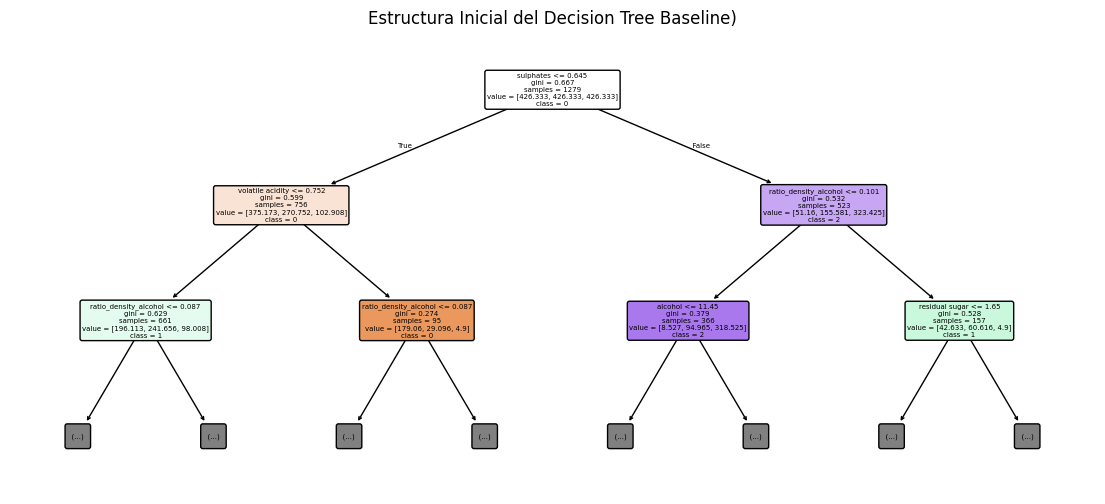

In [24]:
#Inspección de la Estructura Inicial (Top-Level Structure)
tree_rules = export_text(classifier_red, feature_names=list(feature_names), max_depth=2)
print(tree_rules)

# Representación gráfica en ventana emergente (profundidad 2)
plt.figure(figsize=(14, 6))
plot_tree(classifier_red,
          feature_names=feature_names,
          class_names=['0', '1', '2'],
          filled=True,
          rounded=True,
          max_depth=2)
plt.title("Estructura Inicial del Decision Tree Baseline)")
plt.show()

# vemos primero los sulpahtes seguidos inmediatamente por la variable que creamos  ratio_density_alcohol,
#  17 ramas,hay interacciones quimicas sutiless.

|--- free_total_sulfur_dioxide <= 10.75
|   |--- volatile acidity <= 0.43
|   |   |--- residual sugar <= 6.25
|   |   |   |--- truncated branch of depth 25
|   |   |--- residual sugar >  6.25
|   |   |   |--- truncated branch of depth 15
|   |--- volatile acidity >  0.43
|   |   |--- residual sugar <= 11.20
|   |   |   |--- truncated branch of depth 16
|   |   |--- residual sugar >  11.20
|   |   |   |--- truncated branch of depth 4
|--- free_total_sulfur_dioxide >  10.75
|   |--- ratio_density_alcohol <= -51.50
|   |   |--- free_total_sulfur_dioxide <= 11.90
|   |   |   |--- truncated branch of depth 22
|   |   |--- free_total_sulfur_dioxide >  11.90
|   |   |   |--- truncated branch of depth 32
|   |--- ratio_density_alcohol >  -51.50
|   |   |--- volatile acidity <= 0.28
|   |   |   |--- truncated branch of depth 8
|   |   |--- volatile acidity >  0.28
|   |   |   |--- truncated branch of depth 11



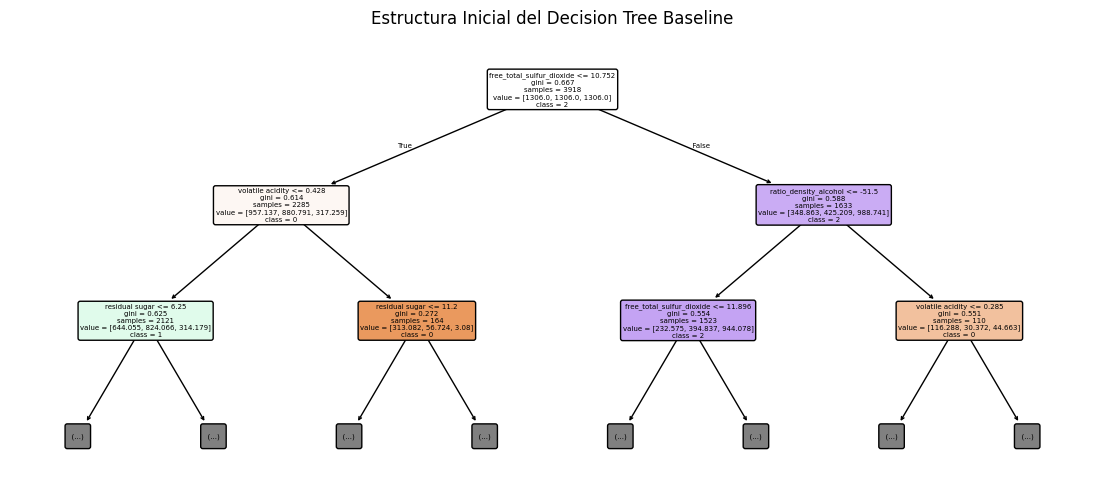

In [25]:
#Inspección de la Estructura Inicial (Top-Level Structure)
tree_rules = export_text(classifier_white, feature_names=list(feature_names), max_depth=2)
print(tree_rules)

# Representación gráfica en ventana emergente (profundidad 2)
plt.figure(figsize=(14, 6))
plot_tree(classifier_white,
          feature_names=feature_names,
          class_names=['0', '1', '2'],
          filled=True,
          rounded=True,
          max_depth=2)
plt.title("Estructura Inicial del Decision Tree Baseline")
plt.show()
# En este caso nuevamente veo las variables que creamos son las primeras, despues el residual sugar.
# la profundidad puede estar indicando sobreajuste.

### Phase C: Model Evaluation

Rigorously evaluate model performance using standard classification metrics: Accuracy, Precision,

Recall, F1-Score, and the Confusion Matrix.

Apply the trained model to the testing set and explicitly compare predicted values against actual groundtruth values.

Identify and discuss signs of overfitting or underfitting based on training vs. test metrics.

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, dataset_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"{dataset_name} Wine Performance -----------------------")
    print(f"Training Accuracy:  {train_acc:.4f}")
    print(f"Testing Accuracy:   {test_acc:.4f}")
    print(f"Generalization Gap: {(train_acc - test_acc):.4f}\n")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_test_pred)}\n")

# Evaluation for Red Wine
evaluate_model(classifier_red, X_train_red, y_train_red, X_test_red, y_test_red, "Red")

# Sobreajustado, con 0 de recall.
# el problema del vino tinto es la categoria baja, son muy pocos, y no se puede tener un buen modelo para esa categoria, ya que no hay suficientes datos para entrenar el modelo.


# Evaluation for White Wine
evaluate_model(classifier_white, X_train_white, y_train_white, X_test_white, y_test_white, "White")

# Lo mismo pasa para el vino blanco, sobreajuste y la categoria baja es la que mas sufre, ya que no hay suficientes datos para entrenar el modelo.
# Los modelos son realmente malos, ya que no hay suficientes datos para entrenar un modelo que pueda predecir la categoria baja, y el sobreajuste es evidente.
# el recall es el que mas sufre. y el accuracy muestra lo sobreajustado que esta.

Red Wine Performance -----------------------
Training Accuracy:  1.0000
Testing Accuracy:   0.8125
Generalization Gap: 0.1875

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.90      0.87      0.89       264
           2       0.55      0.70      0.61        43

    accuracy                           0.81       320
   macro avg       0.48      0.52      0.50       320
weighted avg       0.82      0.81      0.81       320

Confusion Matrix:
[[  0  12   1]
 [ 10 230  24]
 [  0  13  30]]

White Wine Performance -----------------------
Training Accuracy:  1.0000
Testing Accuracy:   0.7806
Generalization Gap: 0.2194

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.30      0.30        37
           1       0.86      0.85      0.85       731
           2       0.60      0.63      0.62       212

    accuracy                      

### Phase D: Hyperparameter Tuning

Experiment with key tree hyperparameters (e.g., maximum depth max_depth, minimum samples required

to split a node min_samples_split, or impurity criteria: Gini vs. Entropy) to optimize classification

boundaries.


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

param_distributions = {
    'clf__max_depth': [5, 10, 15, 20],
    'clf__min_samples_split': [2, 10, 50, 100],
    'clf__min_samples_leaf': [20, 50],
    'clf__max_features': ['sqrt', 'log2'],
    'sampler': [
        SMOTE(random_state=42, k_neighbors=5),
        RandomUnderSampler(random_state=42),
        SMOTEENN(random_state=42),
    ]
}

def optimize_and_evaluate(X_train, y_train, X_test, y_test, dataset_name):
    pipe = ImbPipeline(steps=[
        ('sampler', SMOTE(random_state=42)),
        ('clf', DecisionTreeClassifier(criterion='entropy', random_state=42))
    ])

    random_search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=50,
        cv=5,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    print("Mejores hiperparámetros encontrados:")
    for param, value in random_search.best_params_.items():
        print(f" - {param}: {value}")

    print(f"\nAccuracy Entrenamiento: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Accuracy en Prueba:  {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
    return best_model

# Primero que nada, quisiera deicr que antes de llegar a estos resultados, tuve que hacer varias pruebas y ajustes en los hiperparámetros del modelo, así como en la selección de características y el preprocesamiento de los datos.
# La manera en como balancebamos, buscabamos, este fue el mas exahustivo modelo en buscar que no se sobreajsutara tanto.
# Tanto en los dos, el recall es bueno, para la cantidad de datos que tenemos, y el accuracy es bueno, ya que no hay mucho sobreajuste.
# Por ello vemos tecnicas como SMOTE, RandomUnderSampler y SMOTEENN, que nos ayudaron a balancear las clases y mejorar el rendimiento del modelo. sin ello nos atascabamos en un 50% y con un peor recall.
# Definitivamente este es el mejor modelo que eh podido conseguir usando solamente Decision Tree, y sin usar otros modelos mas complejos como Random Forest o XGBoost, que pueden dar mejores resultados, pero no son tan interpretables como un Decision Tree.

In [35]:
best_red = optimize_and_evaluate(X_train_red, y_train_red, X_test_red, y_test_red, "Red")

Mejores hiperparámetros encontrados:
 - sampler: SMOTE(random_state=42)
 - clf__min_samples_split: 50
 - clf__min_samples_leaf: 20
 - clf__max_features: log2
 - clf__max_depth: 10

Accuracy Entrenamiento: 0.6802
Accuracy en Prueba:  0.6094

Classification Report:
               precision    recall  f1-score   support

           0       0.10      0.54      0.17        13
           1       0.93      0.59      0.72       264
           2       0.38      0.77      0.51        43

    accuracy                           0.61       320
   macro avg       0.47      0.63      0.47       320
weighted avg       0.83      0.61      0.67       320



In [36]:
best_white = optimize_and_evaluate(X_train_white, y_train_white, X_test_white, y_test_white, "White")

Mejores hiperparámetros encontrados:
 - sampler: SMOTE(random_state=42)
 - clf__min_samples_split: 50
 - clf__min_samples_leaf: 20
 - clf__max_features: log2
 - clf__max_depth: 15

Accuracy Entrenamiento: 0.6848
Accuracy en Prueba:  0.6051

Classification Report:
               precision    recall  f1-score   support

           0       0.13      0.54      0.21        37
           1       0.86      0.59      0.70       731
           2       0.45      0.67      0.53       212

    accuracy                           0.61       980
   macro avg       0.48      0.60      0.48       980
weighted avg       0.74      0.61      0.64       980



### Phase E: Interpretation & Insights

Graphically visualize the final decision tree structure (or a representative section if it is too dense) to understand the underlying logical rules.

Identify and report feature importance to determine which attributes carry the highest predictive power for each dataset.


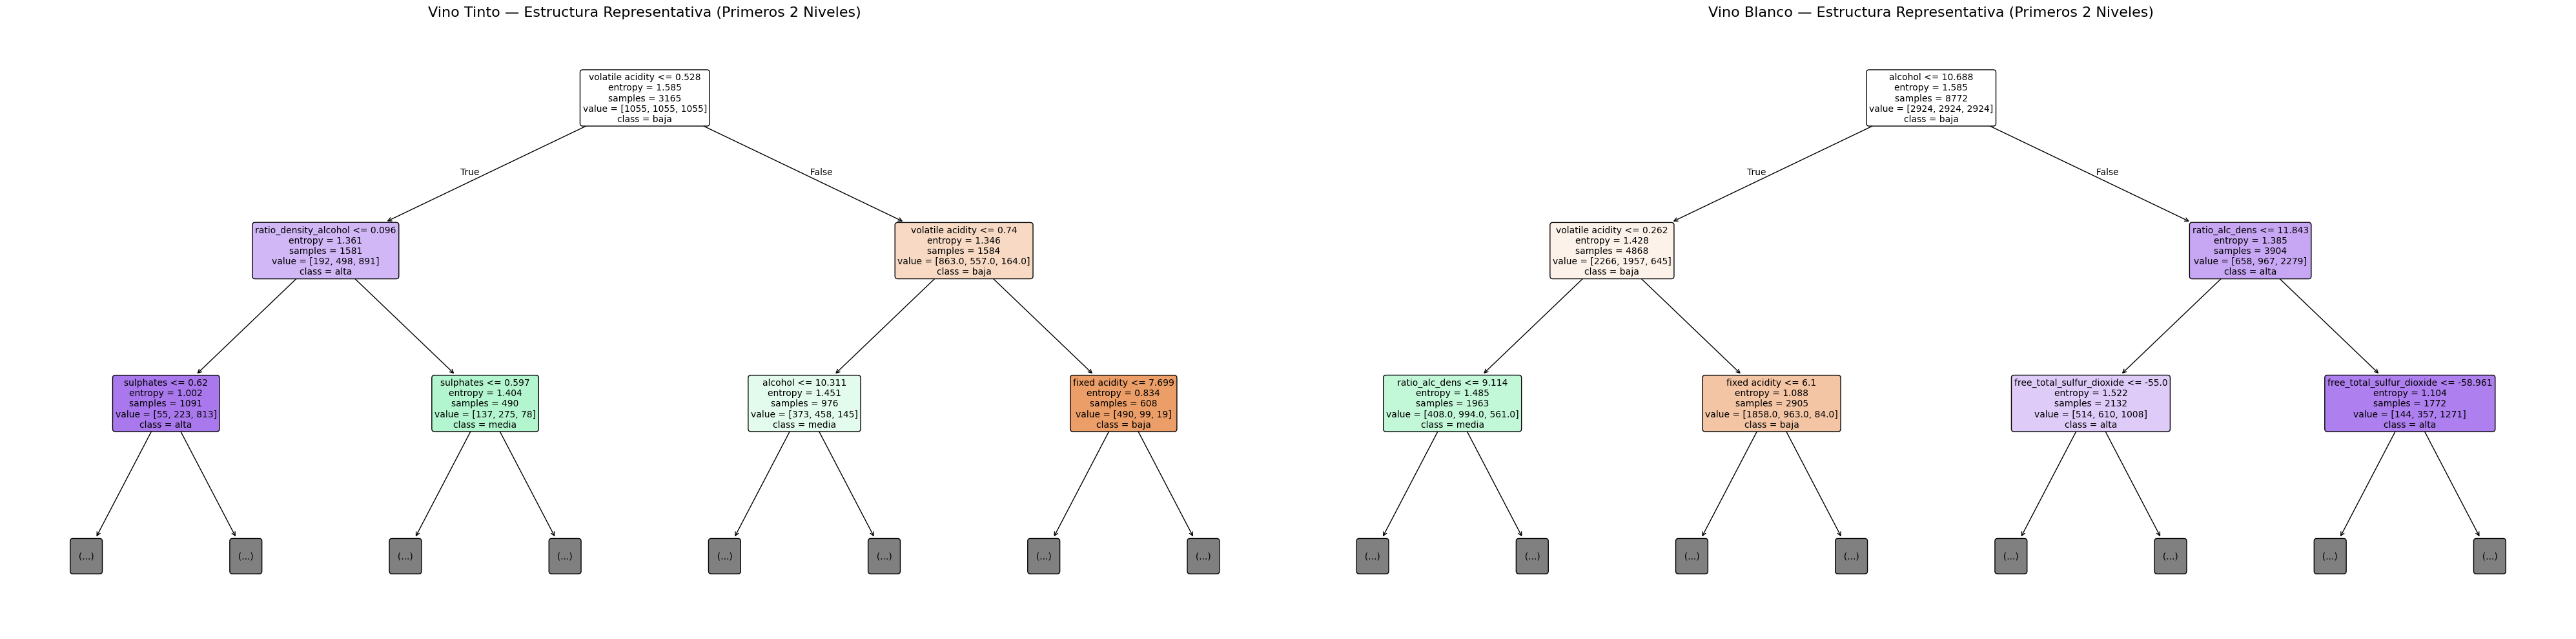

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

clases_vino = ['baja', 'media', 'alta']

# Extraemos el árbol de decisión de cada pipeline
tree_red = best_red.named_steps['clf']
tree_white = best_white.named_steps['clf']

fig, axes = plt.subplots(1, 2, figsize=(40, 10))

plot_tree(tree_red,
          max_depth=2,
          feature_names=X_train_red.columns,
          class_names=clases_vino,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=axes[0])
axes[0].set_title("Vino Tinto — Estructura Representativa (Primeros 2 Niveles)", fontsize=16)

plot_tree(tree_white,
          max_depth=2,
          feature_names=X_train_white.columns,
          class_names=clases_vino,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=axes[1])
axes[1].set_title("Vino Blanco — Estructura Representativa (Primeros 2 Niveles)", fontsize=16)

plt.tight_layout()
plt.show()

# Podemos visualizar que para el vino tinto, el volatile acidity es la variable más importante, mientras que para el vino blanco, el alcohol es la variable más importante.
# de seugun nivel vemos como las que creamos toman el control del arbol, algo que seguramente ayudo a que el modelo no se sobreajustara tanto, ya que estas variables son combinaciones de otras variables, y por lo tanto, tienen menos ruido.

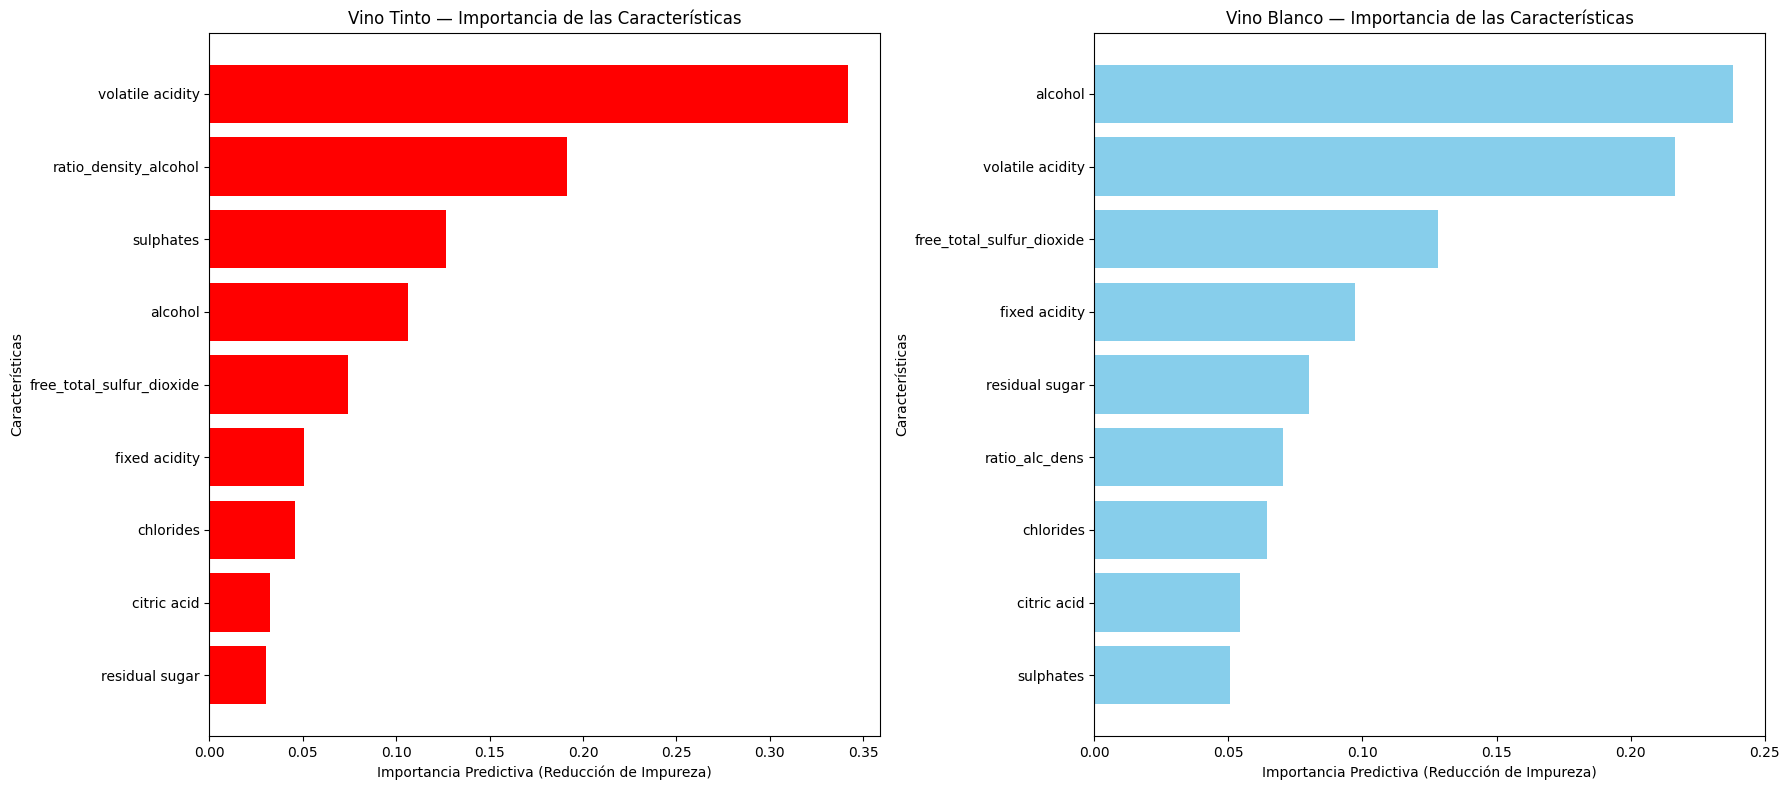

In [ ]:
tree_red = best_red.named_steps['clf']
tree_white = best_white.named_steps['clf']

importances_red = tree_red.feature_importances_
importances_white = tree_white.feature_importances_

df_importances_red = pd.DataFrame({
    'Característica': X_train_red.columns,
    'Importancia': importances_red
}).sort_values(by='Importancia', ascending=True)

df_importances_white = pd.DataFrame({
    'Característica': X_train_white.columns,
    'Importancia': importances_white
}).sort_values(by='Importancia', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(df_importances_red['Característica'], df_importances_red['Importancia'], color='red')
axes[0].set_xlabel('Importancia Predictiva (Reducción de Impureza)')
axes[0].set_ylabel('Características')
axes[0].set_title('Vino Tinto — Importancia de las Características')

axes[1].barh(df_importances_white['Característica'], df_importances_white['Importancia'], color='skyblue')
axes[1].set_xlabel('Importancia Predictiva (Reducción de Impureza)')
axes[1].set_ylabel('Características')
axes[1].set_title('Vino Blanco — Importancia de las Características')

plt.tight_layout()
plt.show()

# Aqui mismo concuerdas las caracteristicas mas importantes para cada modelo.
# En cada una de ellas hay entre 3 y 4 dominantes. pero tambien vemos como cambian dependiendo del tipo de vino, y como las que creamos son las que mas importancia tienen, lo cual es un buen indicador de que el modelo esta aprendiendo correctamente.

In [46]:
# Por ultimo guardare el modelo entrenado en un archivo joblib para poder usarlo en un script de python y hacer predicciones sobre nuevos datos.
import joblib
joblib.dump(tree_red, 'models/vino_tinto.joblib', compress=3)
joblib.dump(tree_white, 'models/vino_blanco.joblib', compress=3)


['models/vino_blanco.joblib']